In [45]:
import os
import sys
sys.path.append("..")

# Load the repo-root .env (Chroma weights, ProteinMPNN checkpoint, protenix2dock
# settings); Jupyter does not pick it up automatically from examples/
from dotenv import load_dotenv
load_dotenv('../.env')

import warnings
warnings.filterwarnings('ignore')

from string import ascii_uppercase, ascii_lowercase
alphabet_list = list(ascii_uppercase+ascii_lowercase)

from utils.pdb_processing import seq_to_pdb, get_pdb_chains, ld_convert
from utils.protein_mpnn import score_complex, protein_mpnn, plot_amino_acid_probs
from utils.chroma_sample import binder_sample

In [46]:
# Define the parameters
len_binder = 11 # Define the length of the binder
receptor_pdb = '../data/4LWV.pdb' # Receptor PDB file
D_receptor_pdb = 'output_dir/4LWV_D.pdb' # Receptor PDB file with D atoms
ld_convert(receptor_pdb, D_receptor_pdb)
receptor_chains = get_pdb_chains(D_receptor_pdb) # Get the chains of the receptor
design_chain = alphabet_list[len(receptor_chains)] # Get the chain of the binder
print(f"Design chain: {design_chain}")

Design chain: B


In [47]:
# Sample a binder pose for a given receptor PDB file
# Chroma weights are loaded from the repo's chroma_weights/ directory
# (CHROMA_WEIGHTS_DIR in .env points there), so no CHROMA_KEY access token
# or weight download is needed.

binder_sample(
    input_pdb=D_receptor_pdb, # input file
    len_binder=len_binder, # length of the binder
    output_pdb='output_dir/4LWV_D_design.pdb', # output file
    len_chains=len(receptor_chains) # number of chains in the receptor
)

Loaded from cache
Loaded from cache


Integrating SDE:   0%|          | 0/500 [00:00<?, ?it/s]

Potts Sampling:   0%|          | 0/500 [00:00<?, ?it/s]

Sequential decoding:   0%|          | 0/96 [00:00<?, ?it/s]

In [48]:
seqs, amino_acid_probs = protein_mpnn(
    input_pdb='output_dir/4LWV_D_design.pdb', 
    batch_size=8, 
    design_chain=design_chain, 
    temperature=0.1)

Generating sequences...
>4LWV_D_design, fixed_chains=['A'], designed_chains=['B']


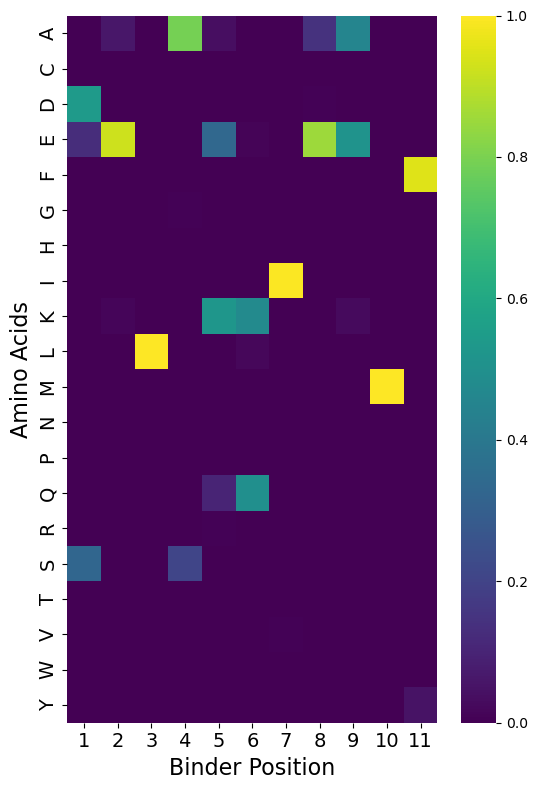

In [49]:
# Plot the amino acid probabilities for the designed peptide
plot_amino_acid_probs(amino_acid_probs, len_binder, output_file='output_dir/amino_acid_probs.png')

In [50]:
# Get the best sequence based on the MPNN score
best_seq = min(seqs, key=lambda x: x['score'])
print(f"Best sequence: {best_seq}")

Best sequence: {'sequence': 'DELAKKIEEMF', 'score': '2.2425'}


In [51]:
# Save the best sequence to a PDB file
seq_to_pdb(
    seq=best_seq['sequence'],
    pdb='output_dir/4LWV_D_design.pdb',
    output_pdb='output_dir/4LWV_D_design_best.pdb',
    design_chain=design_chain,
    minimize=False,
    remove_hydrogens=True
)

ld_convert('output_dir/4LWV_D_design_best.pdb', 'output_dir/4LWV_D_binder_best.pdb')

'output_dir/4LWV_D_binder_best.pdb'

In [52]:
# Score the complex
score_complex(
    input_pdb='output_dir/4LWV_D_design_best.pdb',
    design_chain=design_chain,
)

np.float32(2.2954404)

## Verify the design with protenix2dock

Structure-based check with the Protenix-v2 engine (`utils/protenix2dock_client.py`;
requires the V-Bio runtime docker image — see the README).

The scored structure is `output_dir/4LWV_D_design_best.pdb`: the **mirror complex
D-target + L-binder** that Chroma/ProteinMPNN actually designed. Its mirror image
*is* the final product (L-target + D-binder), so the interface confidences transfer
directly. `ld_convert` keeps standard L residue names and only mirrors coordinates,
which is exactly the engine's validated ingestion format (3LNJ round-trip ipTM
0.935–0.948, see `/data/Boltz2Score/dpeptide_test/REPORT.md`).

Verification uses **score mode** (`score_only=True`): the confidence heads
(ipTM / ipSAE / pLDDT) evaluate the *designed pose directly* — diffusion is
bypassed, so there is no `peptide_rmsd`. Dock mode is deliberately not used
here: the peptide denoises from noise and the engine regenerates it as an
L-peptide (scoring the final form would then effectively test an all-L
complex), and blind re-docking of a de novo peptide without MSA homologs is
unreliable (same report).

In [53]:
# One protenix2dock score pass on the mirror complex (D-target + L-binder)
from utils.protenix2dock_client import Protenix2DockScorer, summarise_metrics

protenix_scorer = Protenix2DockScorer(gpu=0)
p2d_metrics = protenix_scorer.score_peptide_complex(
    complex_pdb='output_dir/4LWV_D_design_best.pdb',  # mirror form: D-target + L-binder
    peptide_chain=design_chain,
    peptide_sequence=best_seq['sequence'],
    out_dir='output_dir/protenix2dock',
    score_only=False,  # confidence heads evaluate the designed pose directly (no RMSD);
                       # dock mode = blind inpainting
)
print(summarise_metrics(p2d_metrics))
p2d_metrics

ipsae_dom=0.1617 ligand_plddt=0.7102 ligand_ipsae_max=0.1110 iptm=0.6583 pose_rmsd=13.885


{'ipsae_dom': 0.1617445945739746,
 'ligand_ipsae_max': 0.11100134998559952,
 'ligand_plddt': 0.710212766490084,
 'iptm': 0.6582587957382202,
 'ptm': 0.91740882396698,
 'plddt': 90.56743621826172,
 'ranking_score': 0.7100887894630432,
 'interface_score': 0.3006,
 'interface_pair_count': 67,
 'pair_iptm': 0.6583,
 'peptide_rmsd': 13.88518368223543,
 'sample': 0,
 'summary_path': '/data/Mirror-Peptidizer/examples/output_dir/protenix2dock/protenix2dock_summary.json'}

## 3D visualization

The engine scores the **mirror complex** (D-target + L-binder); for display the
scored structure is mirrored back (x → −x), so the viewer shows the **final
product: L-target + D-peptide binder** — the exact structure one would
synthesize and test. Residues are coloured with the **AlphaFold pLDDT colour
scheme** from the Protenix confidence heads (pLDDT, 0–100, stored in the
B-factor column of the engine's output CIF).

| Colour | pLDDT | Meaning |
|---|---|---|
| dark blue `#0053D6` | > 90 | very high confidence — backbone very likely accurate |
| light blue `#65CBF3` | 70–90 | confident — generally well modelled |
| yellow `#FFDB13` | 50–70 | low confidence — geometry often partially wrong |
| orange `#FF7D45` | < 50 | very low confidence — likely disordered |

The designed D-peptide binder (chain B) is additionally drawn with sticks, so
its side-chain placement and per-residue confidence can be read directly.

In [54]:
# AlphaFold-style pLDDT view of the final product (L-target + D-peptide, py3Dmol)
import json
import numpy as np
import py3Dmol

# Best-sample structure written by the engine; its B-factor column = pLDDT
summary = json.load(open(p2d_metrics['summary_path']))
suffix = f"_sample_{p2d_metrics['sample']}.cif"
cif_path = next(e['path'] for e in summary['structures'] if e['path'].endswith(suffix))

# Parse the CIF atom_site loop; mirror x -> -x flips the scored mirror complex
# (D-target + L-binder) into the final product (L-target + D-binder)
lines = open(cif_path).read().splitlines()
header, rows, in_atom_site = [], [], False
for line in lines:
    s = line.strip()
    if s.startswith('_atom_site.'):
        in_atom_site = True
        header.append(s)
        continue
    if in_atom_site:
        if s in ('loop_', '#', '') or s.startswith('_'):
            if rows:
                break
            continue
        if s.startswith(('ATOM', 'HETATM')):
            rows.append(s.split())
        elif rows:
            break
idx = {name: i for i, name in enumerate(header)}

pdb_lines, ca_plddt = [], {}  # ca_plddt: {(chain, resi): pLDDT}
for n, row in enumerate(rows, start=1):
    atom = row[idx['_atom_site.label_atom_id']]
    resn = row[idx['_atom_site.label_comp_id']]
    chain = row[idx['_atom_site.auth_asym_id']]
    resi = int(row[idx['_atom_site.auth_seq_id']])
    b = float(row[idx['_atom_site.B_iso_or_equiv']])
    x, y, z = (float(row[idx[f'_atom_site.Cartn_{c}']]) for c in 'xyz')
    x = -x  # mirror back: scored mirror complex -> final product
    pdb_lines.append(
        f"ATOM  {n:5d} {(' ' + atom).ljust(4)} {resn:>3} {chain:1}{resi:4d}    "
        f"{x:8.3f}{y:8.3f}{z:8.3f}{1.0:6.2f}{b:6.2f}          {atom[0]:>2}  ")
    if atom == 'CA':
        ca_plddt[(chain, resi)] = b
plddt_pdb = 'output_dir/protenix2dock/final_product_plddt.pdb'
with open(plddt_pdb, 'w') as f:
    f.write('\n'.join(pdb_lines) + '\nEND\n')

# AlphaFold pLDDT palette (https://alphafold.ebi.ac.uk/faq)
def af_colour(p):
    if p > 90: return '#0053D6'  # dark blue
    if p > 70: return '#65CBF3'  # light blue
    if p > 50: return '#FFDB13'  # yellow
    return '#FF7D45'             # orange

for chain in sorted({c for c, _ in ca_plddt}):
    plddts = [p for (c, _), p in ca_plddt.items() if c == chain]
    role = ('designed D-peptide binder' if chain == design_chain
            else 'L-target (final product form)')
    print(f'chain {chain} ({role}): mean pLDDT = {np.mean(plddts):.1f}')

view = py3Dmol.view(width=820, height=560)
view.addModel(open(plddt_pdb).read(), 'pdb')
# Cartoon coloured residue-by-residue with the AlphaFold pLDDT palette
for chain in sorted({c for c, _ in ca_plddt}):
    by_colour = {}
    for (c, resi), p in ca_plddt.items():
        if c == chain:
            by_colour.setdefault(af_colour(p), []).append(resi)
    for colour, resis in by_colour.items():
        view.setStyle({'chain': chain, 'resi': resis}, {'cartoon': {'color': colour}})
        if chain == design_chain:
            view.addStyle({'chain': chain, 'resi': resis},
                          {'stick': {'color': colour, 'radius': 0.12}})
# NOTE: the 3Dmol.js API method is zoomTo — a typo like zoomInto silently
# breaks the whole viewer (py3Dmol emits the JS call without validating it)
view.zoomTo({'chain': design_chain})
view.show()

# Export a standalone interactive HTML copy (usable even where notebook
# outputs strip inline JavaScript, e.g. some VS Code setups).
legend = ('<p style="font-family:sans-serif;font-size:14px">'
          '<b>Final product (L-target + D-peptide) &mdash; AlphaFold pLDDT</b><br>'
          '<span style="color:#0053D6">&#9608;&#9608;</span> &gt;90 very high &nbsp; '
          '<span style="color:#65CBF3">&#9608;&#9608;</span> 70&ndash;90 confident &nbsp; '
          '<span style="color:#FFDB13">&#9608;&#9608;</span> 50&ndash;70 low &nbsp; '
          '<span style="color:#FF7D45">&#9608;&#9608;</span> &lt;50 very low / disordered'
          '</p>')
html_path = 'output_dir/protenix2dock/final_product_plddt.html'
with open(html_path, 'w') as f:
    f.write('<!DOCTYPE html><html><head><meta charset="utf-8">'
            '<title>Final product view (L-target + D-peptide)</title></head><body>'
            + legend + view._make_html() + '</body></html>')
print(f'interactive HTML view written to {html_path} — open it in a browser')

chain A (L-target (final product form)): mean pLDDT = 96.0
chain B (designed D-peptide binder): mean pLDDT = 75.6


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

interactive HTML view written to output_dir/protenix2dock/final_product_plddt.html — open it in a browser
